## 1. Load data

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["R_DONT_USE_SITE_FILE"] = "TRUE"
os.environ["R_PROFILE_USER"] = "NUL"
os.environ["RPY2_CFFI_MODE"] = "ABI"
os.environ["R_HOME"] = r"home:\\R\\R-4.5.0"
os.environ["PATH"] = r"home:\\R\\R-4.5.0\\bin;" + os.environ["PATH"]

import torch
import pandas as pd
import numpy as np
import scanpy as sc
import sys
sys.path.append("home:/SpatialMuSC/SpatialMuSC-main/SpatialMuSC-main")
import SpatialMuSC
import matplotlib
matplotlib.use("TkAgg")
import matplotlib.pyplot as plt

from sklearn.metrics import normalized_mutual_info_score, mutual_info_score, adjusted_mutual_info_score
from sklearn.metrics import v_measure_score, homogeneity_score, completeness_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

from metric import jaccard, Dice, F_measure

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

file_fold = 'home:/code_data/Dataset11_Human_Lymph_Node_A1/'
GT_path = 'home:/code_data/Dataset11_Human_Lymph_Node_A1/GT_labels.txt'

data_type = '10x'
random_seed = 2022
n_clusters = 10
cluster_method = 'mclust'


Using device: cuda


In [2]:
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ADT.h5ad')

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

print("adata_omics1 shape:", adata_omics1.shape)
print("adata_omics2 shape:", adata_omics2.shape)

adata_omics1

adata_omics1 shape: (3484, 18085)
adata_omics2 shape: (3484, 31)


AnnData object with n_obs × n_vars = 3484 × 18085
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

## 2. RNA preprocessing

In [3]:
from SpatialMuSC.preprocess import fix_seed, clr_normalize_each_cell, pca, construct_neighbor_graph

fix_seed(random_seed)
print("Random seed fixed:", random_seed)

sc.pp.filter_genes(adata_omics1, min_cells=10)
print("After filter_genes, adata_omics1 shape:", adata_omics1.shape)

sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
print("Number of highly variable genes:", adata_omics1.var['highly_variable'].sum())

sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)

adata_omics1_high = adata_omics1[:, adata_omics1.var['highly_variable']]
print("adata_omics1_high shape:", adata_omics1_high.shape)

adata_omics1.obsm['feat'] = pca(adata_omics1_high, n_comps=adata_omics2.n_vars - 1)
print("RNA feat shape:", adata_omics1.obsm['feat'].shape)

Random seed fixed: 2022
After filter_genes, adata_omics1 shape: (3484, 17954)
Number of highly variable genes: 3000
adata_omics1_high shape: (3484, 3000)
RNA feat shape: (3484, 30)


## 3. Protein preprocessing

In [4]:
adata_omics2 = clr_normalize_each_cell(adata_omics2)
sc.pp.scale(adata_omics2)
adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=adata_omics2.n_vars - 1)

print("Protein feat shape:", adata_omics2.obsm['feat'].shape)
adata_omics2

Protein feat shape: (3484, 30)


AnnData object with n_obs × n_vars = 3484 × 31
    var: 'gene_ids', 'feature_types', 'genome', 'mean', 'std'
    obsm: 'spatial', 'feat'

## 4. Model training

In [5]:
data = construct_neighbor_graph(adata_omics1, adata_omics2, datatype=data_type)
print("Neighbor graph constructed.")
type(data)

same true： True
Neighbor graph constructed.


dict

In [6]:
from SpatialMuSC.SpatialMuSC_pyG import Train_SpatialMuSC

model = Train_SpatialMuSC(data, datatype=data_type, device=device)
output = model.train()

print(output.keys())

100%|██████████| 800/800 [03:36<00:00,  3.70it/s]

dict_keys(['emb_latent_omics1', 'emb_latent_omics2', 'SpatialMuSC'])


In [7]:
adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1'].copy()
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2'].copy()
adata.obsm['SpatialMuSC'] = output['SpatialMuSC'].copy()

print("emb_latent_omics1 shape:", adata.obsm['emb_latent_omics1'].shape)
print("emb_latent_omics2 shape:", adata.obsm['emb_latent_omics2'].shape)
print("SpatialMuSC embedding shape:", adata.obsm['SpatialMuSC'].shape)

emb_latent_omics1 shape: (3484, 64)
emb_latent_omics2 shape: (3484, 64)
SpatialMuSC embedding shape: (3484, 64)


## 5. Clustering

In [8]:
from SpatialMuSC.utils import clustering

clustering(
    adata,
    key='SpatialMuSC',
    add_key='SpatialMuSC',
    n_clusters=n_clusters,
    method=cluster_method,
    use_pca=True
)

adata.obs['SpatialMuSC'].head()

R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


AACACTTGGCAAGGAA-1    1
AACAGGATTCATAGTT-1    1
AACAGGTTATTGCACC-1    1
AACAGGTTCACCGAAG-1    2
AACAGTCAGGCTCCGC-1    9
Name: SpatialMuSC, dtype: category
Categories (10, int32): [1, 2, 3, 4, ..., 7, 8, 9, 10]

In [9]:
print("Unique predicted labels:", sorted(adata.obs['SpatialMuSC'].unique()))
print("Number of clusters:", adata.obs['SpatialMuSC'].nunique())

adata.obs['SpatialMuSC'].value_counts().sort_index()

Unique predicted labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of clusters: 10


SpatialMuSC
1     1462
2      385
3       77
4      150
5      874
6       96
7       62
8      114
9      146
10     118
Name: count, dtype: int64

## 6. Evaluation

In [10]:
GT_list = []
with open(GT_path, 'r') as f:
    for line in f:
        GT_list.append(int(line.strip()))

print("GT length:", len(GT_list))
print("GT label set:", sorted(set(GT_list)))
print("GT min/max:", min(GT_list), max(GT_list))

GT length: 3484
GT label set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
GT min/max: 0 9


In [11]:
pred_list = adata.obs['SpatialMuSC'].tolist()
pred_list = [int(x) for x in pred_list]

print("Pred length:", len(pred_list))
print("Pred label set:", sorted(set(pred_list)))
print("Pred min/max:", min(pred_list), max(pred_list))

Pred length: 3484
Pred label set: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Pred min/max: 1 10


In [12]:
print("GT length   :", len(GT_list))
print("Pred length :", len(pred_list))

if len(GT_list) != len(pred_list):
    raise ValueError("The lengths of the ground-truth labels and predicted labels do not match！")
else:
    print("The lengths of the ground-truth labels and predicted labels match. You can proceed with the evaluation.")

GT length   : 3484
Pred length : 3484
The lengths of the ground-truth labels and predicted labels match. You can proceed with the evaluation.


In [13]:
our_jaccard = jaccard(pred_list, GT_list)
our_dice = Dice(pred_list, GT_list)
our_f_measure = F_measure(pred_list, GT_list)

our_mutual_info = mutual_info_score(GT_list, pred_list)
our_nmi = normalized_mutual_info_score(GT_list, pred_list)
our_ami = adjusted_mutual_info_score(GT_list, pred_list)
our_v = v_measure_score(GT_list, pred_list)
our_homogeneity = homogeneity_score(GT_list, pred_list)
our_completeness = completeness_score(GT_list, pred_list)
our_ari = adjusted_rand_score(GT_list, pred_list)
our_fmi = fowlkes_mallows_score(GT_list, pred_list)

print(f"Our         Jaccard: {our_jaccard:.6f}")
print(f"Our         Dice: {our_dice:.6f}")
print(f"Our         F_measure: {our_f_measure:.6f}")
print(f"Our         Mutual Information: {our_mutual_info:.6f}")
print(f"Our         NMI: {our_nmi:.6f}")
print(f"Our         AMI: {our_ami:.6f}")
print(f"Our         V-measure: {our_v:.6f}")
print(f"Our         Homogeneity: {our_homogeneity:.6f}")
print(f"Our         Completeness: {our_completeness:.6f}")
print(f"Our         ARI: {our_ari:.6f}")
print(f"Our         FMI: {our_fmi:.6f}")

Our         Jaccard: 0.339985
Our         Dice: 0.507446
Our         F_measure: 0.507446
Our         Mutual Information: 0.696642
Our         NMI: 0.410812
Our         AMI: 0.406584
Our         V-measure: 0.410812
Our         Homogeneity: 0.412946
Our         Completeness: 0.408699
Our         ARI: 0.349962
Our         FMI: 0.508439


## 7. Visualization

In [14]:
sc.pp.neighbors(adata, use_rep='SpatialMuSC', n_neighbors=10)
sc.tl.umap(adata)

print("UMAP finished.")

UMAP finished.


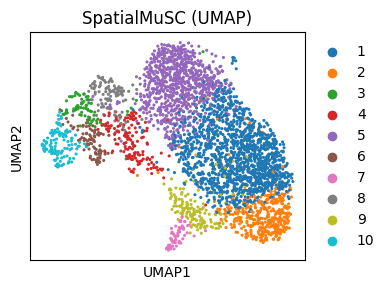

In [15]:
# UMAP only
%matplotlib inline
fig_u, ax_u = plt.subplots(figsize=(4, 3))
sc.pl.umap(
    adata,
    color='SpatialMuSC',
    ax=ax_u,
    title='SpatialMuSC (UMAP)',
    s=20,
    show=False
)
plt.tight_layout()
plt.show()

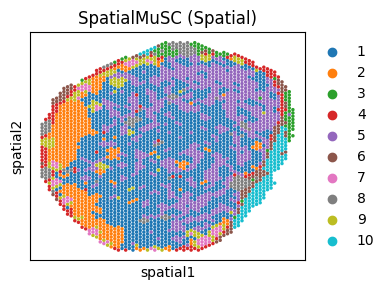

In [16]:
# Spatial only
fig_s, ax_s = plt.subplots(figsize=(4, 3))
sc.pl.embedding(
    adata,
    basis='spatial',
    color='SpatialMuSC',
    ax=ax_s,
    title='SpatialMuSC (Spatial)',
    s=25,
    show=False
)
plt.tight_layout()
plt.show()